# Random Forests

## 1. Loading CTR data, Linear Regression, and CART

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import graphviz
import re
import math
from IPython.display import display

# --- Helper Functions Provided by User ---

def show_head_tail(df, n=3, m=3):
    """
    Displays the head and tail of a DataFrame separated by an ellipsis.

    Args:
        df (pd.DataFrame): The DataFrame to display.
        n (int): The number of rows to show for the head.
        m (int): The number of rows to show for the tail.
    """
    if not isinstance(df, pd.DataFrame):
        print("Input must be a pandas DataFrame.")
        return

    # Create a separator DataFrame filled with '...'
    separator = pd.DataFrame([['...'] * len(df.columns)],
                             columns=df.columns,
                             index=['...'])

    # Concatenate the head, separator, and tail
    combined_df = pd.concat([df.head(n), separator, df.tail(m)])

    display(combined_df)

def significance_stars(p):
    """Converts a p-value to a significance star string."""
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model_results):
    """
    Prints the statsmodels summary table with significance stars.

    Args:
        model_results: A fitted statsmodels result object.
    """
    summary_table = model_results.summary2().tables[1]
    p_col = "P>|z|" if "P>|z|" in summary_table.columns else "P>|t|"
    summary_table['Signif.'] = summary_table[p_col].apply(significance_stars)

    # Reorder columns to place significance stars at the end
    cols = summary_table.columns.tolist()
    cols.insert(len(cols), cols.pop(cols.index('Signif.')))
    summary_table = summary_table.loc[:, cols]

    # Print formatted table
    print(model_results.summary2().tables[0])
    print("\n--- Coefficients ---")
    print(summary_table.to_string())
    print("-" * 40)
    print("Significance codes: 0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1")

def osr2(y_true, y_pred, baseline_mean):
    """
    Calculates the out-of-sample R-squared.

    Args:
        y_true (pd.Series): The true target values.
        y_pred (np.array): The predicted values.
        baseline_mean (float): The mean of the training set's target variable.
    """
    sst = np.sum((y_true - baseline_mean) ** 2)
    sse = np.sum((y_pred - y_true) ** 2)
    if sst == 0: # Avoid division by zero
        return -np.inf if sse > 0 else 1.0
    return 1 - sse / sst

# --- Custom Tree Plotting Function (Modified for Regression) ---

def plot_tree_graphviz(model, feat_names, max_depth=3, title=None, export=False):
    """
    Generates and displays a customized decision tree plot.

    Args:
        model (DecisionTreeRegressor): The trained scikit-learn tree model.
        feat_names (list): A list of feature names.
        max_depth (int): The maximum depth of the tree to display.
        title (str, optional): An optional title for the graph.
        export (bool): If True, exports the plot as a PNG image to the current directory.
    """
    dot = graphviz.Digraph(
        'tree',
        node_attr={'shape': 'box', 'style': 'rounded,filled', 'fontname': 'helvetica'},
        edge_attr={'fontname': 'helvetica', 'fontsize': '12'}
    )
    dot.attr('graph', rankdir='TB', label=title or '', fontname='helvetica', fontsize='16')

    tree_ = model.tree_

    def build_graph_recursive(node_id=0, depth=0):
        is_leaf = tree_.children_left[node_id] == tree_.children_right[node_id]

        if is_leaf:
            leaf_value = f"{tree_.value[node_id][0][0]:.3f}"
            dot.node(str(node_id), label=leaf_value, shape='oval', fillcolor='lightgoldenrodyellow')
        else:
            feature_index = tree_.feature[node_id]
            threshold = tree_.threshold[node_id]
            split_condition = f"{feat_names[feature_index]} < {threshold:.3f}"
            dot.node(str(node_id), label=split_condition, fillcolor='white')

            if depth < max_depth - 1:
                left_child_id = tree_.children_left[node_id]
                right_child_id = tree_.children_right[node_id]

                dot.edge(str(node_id), str(left_child_id), label='yes')
                dot.edge(str(node_id), str(right_child_id), label='no')

                build_graph_recursive(left_child_id, depth + 1)
                build_graph_recursive(right_child_id, depth + 1)
            else:
                left_ellipsis_id = f"ellipsis_left_{node_id}"
                right_ellipsis_id = f"ellipsis_right_{node_id}"

                dot.node(left_ellipsis_id, label="...", shape='plaintext')
                dot.edge(str(node_id), left_ellipsis_id, label='yes')

                dot.node(right_ellipsis_id, label="...", shape='plaintext')
                dot.edge(str(node_id), right_ellipsis_id, label='no')

    build_graph_recursive()

    # --- Added Export Logic ---
    if export:
        # Saves the graph to 'tree.png' and removes the intermediate source file
        dot.render('tree', format='png', cleanup=True)
        print("Tree exported to 'tree.png'")

    display(dot)

# --- Main Script ---

# 1. Import data
print("### 1. Importing Data ###")
try:
    dat = pd.read_csv("CTR.csv")
    print("Successfully loaded CTR.csv")
    print(f"Shape of the data: {dat.shape}")
except FileNotFoundError:
    print("Error: CTR.csv not found.")
    print("Please make sure the 'CTR.csv' file is in the same directory as this script.")
    exit()

### 1. Importing Data ###
Successfully loaded CTR.csv
Shape of the data: (6057, 11)


In [2]:
# 2. Training/test split
print("\n### 2. Preparing and Splitting Data ###")
# Separate features (X) and target (y)
X = dat.drop('CTR', axis=1)
y = dat['CTR']

# Convert all categorical variables to numeric dummy variables.
print("Converting categorical columns to dummy variables...")
X = pd.get_dummies(X, drop_first=True, dtype=float)
print(f"Shape of feature matrix after creating dummies: {X.shape}")


# Perform the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=144
)
print(f"Training set size: {len(X_train)} rows")
print(f"Test set size: {len(X_test)} rows")


# 3. Display Data
print("\n### 3. Displaying Data Subsets ###")
# Recombine for display purposes to match R script
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)
full_disp = pd.concat([dat]).sort_index() # Use original dat for a true full view

print("\n--- Full dataset (recombined) ---")
show_head_tail(full_disp, n=7, m=5)

print("\n--- Training set ---")
show_head_tail(df_train, n=7, m=5)

print("\n--- Specific columns ---")

cols_to_show = dat.columns[[0, 1, 2, 3]]

print("\n--- Specific columns from full dataset ---")
show_head_tail(dat[cols_to_show].sort_index(), n=8, m=2)

print("\n--- Specific columns from training set ---")
# Note: Dummies will change columns, so we select original columns from original df
show_head_tail(df_train[cols_to_show].sort_index(), n=4, m=2)
print(len(df_train))


print("\n--- Specific columns from test set ---")
# Note: Dummies will change columns, so we select original columns from original df
show_head_tail(df_test[cols_to_show].sort_index(), n=4, m=2)
print(len(df_test))


### 2. Preparing and Splitting Data ###
Converting categorical columns to dummy variables...
Shape of feature matrix after creating dummies: (6057, 16)
Training set size: 4239 rows
Test set size: 1818 rows

### 3. Displaying Data Subsets ###

--- Full dataset (recombined) ---


,CTR,titleWords,adWords,depth,position,advCTR,advCTRInPos,queryCTR,queryCTRInPos,gender,age
0,0.0,10,17,3,2,0.0136,0.0146,0.0,0.0,male,41+
1,0.0761,13,30,2,1,0.0373,0.0465,0.0382,0.0581,male,13-18
2,0.0426,12,14,1,1,0.0254,0.031,0.0255,0.0323,male,13-18
3,0.0,5,19,3,2,0.0178,0.0076,0.0035,0.0017,female,25-30
4,0.0068,11,17,2,2,0.0096,0.0069,0.0294,0.0171,female,19-24
5,0.0,15,28,2,2,0.0307,0.0157,0.0324,0.0137,female,31-40
6,0.0383,10,20,3,1,0.0283,0.0338,0.0219,0.0353,female,13-18
...,...,...,...,...,...,...,...,...,...,...,...
6052,0.0182,8,16,1,1,0.0273,0.0356,0.004,0.0,unknown,unknown
6053,0.0536,6,20,1,1,0.0919,0.0982,0.0,0.0,female,19-24



--- Training set ---


,titleWords,adWords,depth,position,advCTR,advCTRInPos,queryCTR,queryCTRInPos,gender_male,gender_unknown,age_13-18,age_19-24,age_25-30,age_31-40,age_41+,age_unknown,CTR
797,11,25,2,1,0.018,0.0296,0.0436,0.0645,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0593
4174,12,31,2,1,0.0337,0.0476,0.0096,0.0225,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0529
1770,16,26,2,1,0.0442,0.0486,0.0754,0.1751,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0667
5491,13,28,1,1,0.0354,0.0618,0.0204,0.0248,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0348
839,4,20,1,1,0.0759,0.078,0.028,0.0395,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.1172
1547,7,14,3,3,0.0223,0.0077,0.0124,0.0055,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1605,8,21,3,1,0.0426,0.0491,0.0175,0.0242,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3715,10,25,2,2,0.0113,0.002,0.0769,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1446,10,13,2,1,0.026,0.0357,0.0293,0.0418,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0994



--- Specific columns ---

--- Specific columns from full dataset ---


...


--- Specific columns from training set ---


,CTR,titleWords,adWords,depth
2,0.0426,12,14,1
3,0.0,5,19,3
4,0.0068,11,17,2
5,0.0,15,28,2
...,...,...,...,...
6052,0.0182,8,16,1
6054,0.0141,9,26,3


4239

--- Specific columns from test set ---


,CTR,titleWords,adWords,depth
0,0.0,10,17,3
1,0.0761,13,30,2
8,0.1015,8,20,2
14,0.025,9,23,2
...,...,...,...,...
6055,0.1339,9,16,2
6056,0.1322,12,23,2


1818


In [3]:
# 4. Linear Regression
print("\n### 4. Linear Regression ###")
# Add a constant (intercept) to the feature matrix
X_train_lm = sm.add_constant(X_train, has_constant='add')
X_test_lm = sm.add_constant(X_test, has_constant='add')

# Align test columns to train columns to ensure prediction works
X_test_lm = X_test_lm.reindex(columns=X_train_lm.columns, fill_value=0)

# Model fitting
mod_lm = sm.OLS(y_train, X_train_lm).fit()

# Display model summary
print("\n--- Linear Regression Model Summary ---")
print_summary_with_stars(mod_lm)

# Prediction on the test set
pred_lm = mod_lm.predict(X_test_lm)

# Assessment of out-of-sample performance
print("\n--- Linear Regression Performance ---")
osr2_lm = osr2(y_test, pred_lm, y_train.mean())
mae_lm = mean_absolute_error(y_test, pred_lm)
rmse_lm = np.sqrt(mean_squared_error(y_test, pred_lm))
print(f"Out-of-Sample R2: {osr2_lm:.4f}")
print(f"MAE: {mae_lm:.4f}")
print(f"RMSE: {rmse_lm:.4f}")


### 4. Linear Regression ###

--- Linear Regression Model Summary ---
                     0                 1                    2            3
0               Model:               OLS      Adj. R-squared:        0.433
1  Dependent Variable:               CTR                 AIC:  -11874.3797
2                Date:  2026-09-06 13:00                 BIC:  -11766.3943
3    No. Observations:              4239      Log-Likelihood:       5954.2
4            Df Model:                16         F-statistic:        203.5
5        Df Residuals:              4222  Prob (F-statistic):         0.00
6           R-squared:             0.435               Scale:    0.0035419

--- Coefficients ---
                   Coef.  Std.Err.          t         P>|t|    [0.025    0.975] Signif.
const           0.007181  0.009212   0.779570  4.356878e-01 -0.010879  0.025242        
titleWords     -0.000391  0.000348  -1.122063  2.618996e-01 -0.001074  0.000292        
adWords         0.000195  0.000219   0.8886


### 5. Classification and Regression Tree (CART) ###
Running GridSearchCV for CART... (This may take a moment)
GridSearchCV complete.

Best ccp_alpha found: 0.0000

--- CART Performance ---
Out-of-Sample R2: 0.3377
MAE: 0.0340
RMSE: 0.0577

--- Plotting Final CART Tree (sklearn.plot_tree) ---


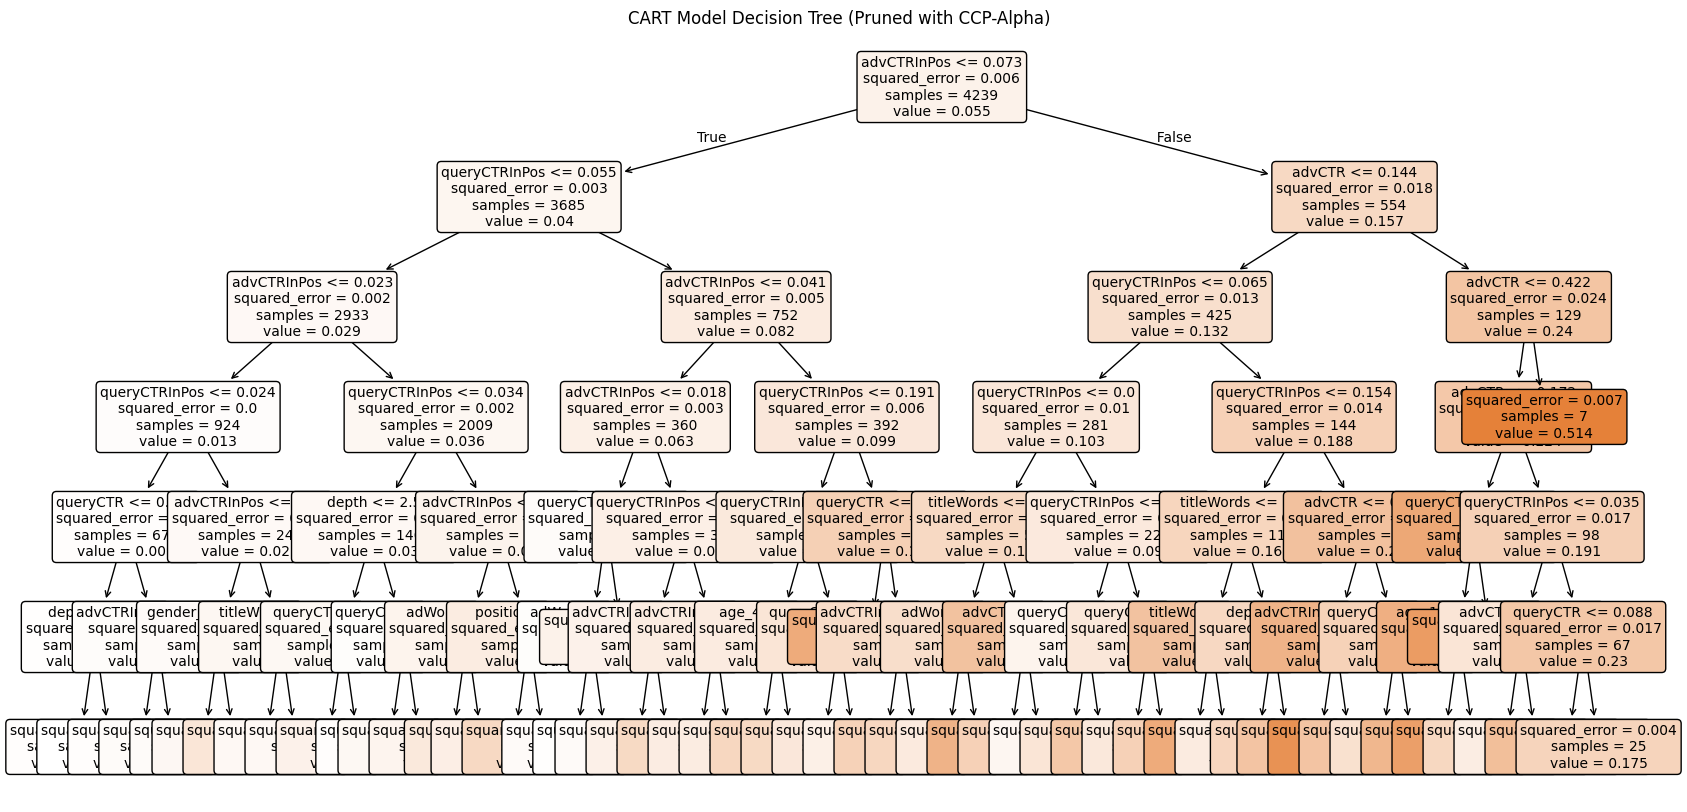


--- Plotting Final CART Tree (Custom Graphviz) ---
Tree exported to 'tree.png'


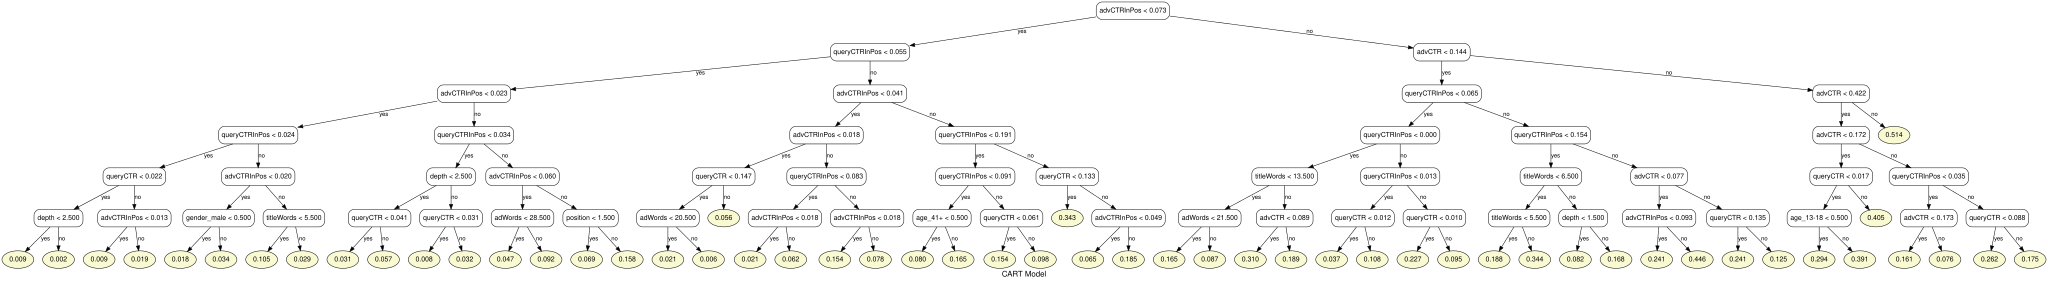


### 6. Performance Summary of All Models ###
                    OSR^2     MAE    RMSE
Linear Regression  0.3961  0.0331  0.0551
CART               0.3377  0.0340  0.0577


In [4]:
# 5. CART
print("\n### 5. Classification and Regression Tree (CART) ###")
param_grid = {'ccp_alpha': np.arange(0, 0.2, 0.005)}

# Define the model with base parameters
modClass = DecisionTreeRegressor(
    min_samples_leaf=5,
    max_depth=6
)

cv_strategy = KFold(n_splits=10, shuffle=True, random_state=144)

search = GridSearchCV(
    estimator=modClass,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

print("Running GridSearchCV for CART... (This may take a moment)")
search.fit(X_train, y_train)
print("GridSearchCV complete.")

mod_cart = search.best_estimator_
print(f"\nBest ccp_alpha found: {mod_cart.ccp_alpha:.4f}")

pred_cart = mod_cart.predict(X_test)

print("\n--- CART Performance ---")
osr2_cart = osr2(y_test, pred_cart, y_train.mean())
mae_cart = mean_absolute_error(y_test, pred_cart)
rmse_cart = np.sqrt(mean_squared_error(y_test, pred_cart))
print(f"Out-of-Sample R2: {osr2_cart:.4f}")
print(f"MAE: {mae_cart:.4f}")
print(f"RMSE: {rmse_cart:.4f}")

# Plotting the final tree (sklearn.plot_tree)
print("\n--- Plotting Final CART Tree (sklearn.plot_tree) ---")
plt.figure(figsize=(20, 10))
plot_tree(
    mod_cart,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10,
#     max_depth=3 # Limit depth for readability
)
plt.title("CART Model Decision Tree (Pruned with CCP-Alpha)")
plt.show()

# Plotting the final tree (Custom Graphviz)
print("\n--- Plotting Final CART Tree (Custom Graphviz) ---")
plot_tree_graphviz(
    mod_cart,
    feat_names=X.columns.tolist(),
    max_depth=math.inf,
    export=True,
    title="CART Model"
)

# 6. Performance Summary
print("\n### 6. Performance Summary of All Models ###")
summary_stats = pd.DataFrame({
    'OSR^2': [osr2_lm, osr2_cart],
    'MAE': [mae_lm, mae_cart],
    'RMSE': [rmse_lm, rmse_cart]
}, index=['Linear Regression', 'CART'])

print(summary_stats.round(4))

## 2. Bootstrapping

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from IPython.display import display

# --- Helper Function ---

def show_head_tail(df, n=3, m=3):
    """
    Displays the head and tail of a DataFrame separated by an ellipsis.

    Args:
        df (pd.DataFrame): The DataFrame to display.
        n (int): The number of rows to show for the head.
        m (int): The number of rows to show for the tail.
    """
    if not isinstance(df, pd.DataFrame):
        print("Input must be a pandas DataFrame.")
        return

    # Create a separator DataFrame filled with '...'
    separator = pd.DataFrame([['...'] * len(df.columns)],
                             columns=df.columns,
                             index=['...'])

    # Concatenate the head, separator, and tail
    combined_df = pd.concat([df.head(n), separator, df.tail(m)])

    display(combined_df)

# --- Main Script ---

# 1. Import data
print("### 1. Importing Data ###")
try:
    dat = pd.read_csv("CTR.csv")
    print("Successfully loaded CTR.csv")
except FileNotFoundError:
    print("Error: CTR.csv not found.")
    exit()

# 2. Create a training set to sample from
# We do this to mimic the scenario where bootstrapping is actually used.
# We will NOT create dummy variables for this demonstration.
print("\n### 2. Creating a Training Set ###")
X = dat.drop('CTR', axis=1)
y = dat['CTR']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=144
)

# Recombine into a single training DataFrame for the demonstration
df_train = pd.concat([X_train, y_train], axis=1)
print(f"Original training set has {len(df_train)} rows.")


# 3. Bootstrapping Demonstration
print("\n### 3. Bootstrapping Demonstration ###")

# Create a bootstrap sample: sample with replacement, same size as original
df_bootstrap = df_train.sample(n=len(df_train), replace=True, random_state=42)

# Sort by index to easily see duplicated rows, similar to the slide
df_bootstrap = df_bootstrap.sort_index()

print(f"Bootstrap sample also has {len(df_bootstrap)} rows.")

print("\n--- Original Training Set ---")
show_head_tail(df_train.sort_index(), n=7, m=3)

print("\n--- Bootstrapped Sample (sorted to show duplicates) ---")
show_head_tail(df_bootstrap.sort_index(), n=7, m=3)

print("\n--- Original Training Set ---")
show_head_tail(df_train.iloc[:, [0,1,2,3,4,5]].sort_index(), n=7, m=3)

print("\n--- Bootstrapped Sample (sorted to show duplicates) ---")
show_head_tail(df_bootstrap.iloc[:, [0,1,2,3,4,5]].sort_index(), n=7, m=3)


### 1. Importing Data ###
Successfully loaded CTR.csv

### 2. Creating a Training Set ###
Original training set has 4239 rows.

### 3. Bootstrapping Demonstration ###
Bootstrap sample also has 4239 rows.

--- Original Training Set ---


,titleWords,adWords,depth,position,advCTR,advCTRInPos,queryCTR,queryCTRInPos,gender,age,CTR
2,12,14,1,1,0.0254,0.031,0.0255,0.0323,male,13-18,0.0426
3,5,19,3,2,0.0178,0.0076,0.0035,0.0017,female,25-30,0.0
4,11,17,2,2,0.0096,0.0069,0.0294,0.0171,female,19-24,0.0068
5,15,28,2,2,0.0307,0.0157,0.0324,0.0137,female,31-40,0.0
6,10,20,3,1,0.0283,0.0338,0.0219,0.0353,female,13-18,0.0383
7,9,23,3,1,0.0054,0.0084,0.0183,0.0208,male,25-30,0.0172
9,11,21,2,1,0.018,0.0314,0.0216,0.0296,female,13-18,0.0125
...,...,...,...,...,...,...,...,...,...,...,...
6051,10,15,3,2,0.0292,0.0303,0.0145,0.0136,male,19-24,0.0
6052,8,16,1,1,0.0273,0.0356,0.004,0.0,unknown,unknown,0.0182



--- Bootstrapped Sample (sorted to show duplicates) ---


,titleWords,adWords,depth,position,advCTR,advCTRInPos,queryCTR,queryCTRInPos,gender,age,CTR
2,12,14,1,1,0.0254,0.031,0.0255,0.0323,male,13-18,0.0426
2,12,14,1,1,0.0254,0.031,0.0255,0.0323,male,13-18,0.0426
2,12,14,1,1,0.0254,0.031,0.0255,0.0323,male,13-18,0.0426
3,5,19,3,2,0.0178,0.0076,0.0035,0.0017,female,25-30,0.0
4,11,17,2,2,0.0096,0.0069,0.0294,0.0171,female,19-24,0.0068
4,11,17,2,2,0.0096,0.0069,0.0294,0.0171,female,19-24,0.0068
4,11,17,2,2,0.0096,0.0069,0.0294,0.0171,female,19-24,0.0068
...,...,...,...,...,...,...,...,...,...,...,...
6051,10,15,3,2,0.0292,0.0303,0.0145,0.0136,male,19-24,0.0
6051,10,15,3,2,0.0292,0.0303,0.0145,0.0136,male,19-24,0.0



--- Original Training Set ---


,titleWords,adWords,depth,position,advCTR,advCTRInPos
2,12,14,1,1,0.0254,0.031
3,5,19,3,2,0.0178,0.0076
4,11,17,2,2,0.0096,0.0069
5,15,28,2,2,0.0307,0.0157
6,10,20,3,1,0.0283,0.0338
7,9,23,3,1,0.0054,0.0084
9,11,21,2,1,0.018,0.0314
...,...,...,...,...,...,...
6051,10,15,3,2,0.0292,0.0303
6052,8,16,1,1,0.0273,0.0356



--- Bootstrapped Sample (sorted to show duplicates) ---


,titleWords,adWords,depth,position,advCTR,advCTRInPos
2,12,14,1,1,0.0254,0.031
2,12,14,1,1,0.0254,0.031
2,12,14,1,1,0.0254,0.031
3,5,19,3,2,0.0178,0.0076
4,11,17,2,2,0.0096,0.0069
4,11,17,2,2,0.0096,0.0069
4,11,17,2,2,0.0096,0.0069
...,...,...,...,...,...,...
6051,10,15,3,2,0.0292,0.0303
6051,10,15,3,2,0.0292,0.0303


## 3. RF on CTR data

### Out-of-sample hyperparameter tuning (CV)

### 1. Importing and Preparing Data ###
Successfully loaded CTR.csv
Training set: (4239, 16), Test set: (1818, 16)

### 2. Baseline Models ###
Fitting Baseline Linear Regression...
Linear Regression performance calculated.
Fitting Baseline CART Model...
Timing a single CART model fit...
Time to fit one single CART model: 47.05 ms
CART GridSearchCV fit time: 3316.67 ms
CART performance calculated.

### 3. Ad-hoc Random Forest Models ###
Fitting RF Model 1 (nodesize=5, max_features=3)...
Model 1 performance calculated.
Fitting RF Model 2 (nodesize=20, max_features=2, ntree=500)...
Model 2 performance calculated.

### 4. Tuning `max_features` with 10-Fold CV ###
Testing max_features = 1...
Testing max_features = 2...
Testing max_features = 3...
Testing max_features = 4...
Testing max_features = 5...
Testing max_features = 6...
Testing max_features = 7...
Testing max_features = 8...
Testing max_features = 9...
Testing max_features = 10...
Testing max_features = 11...
Testing max_features =

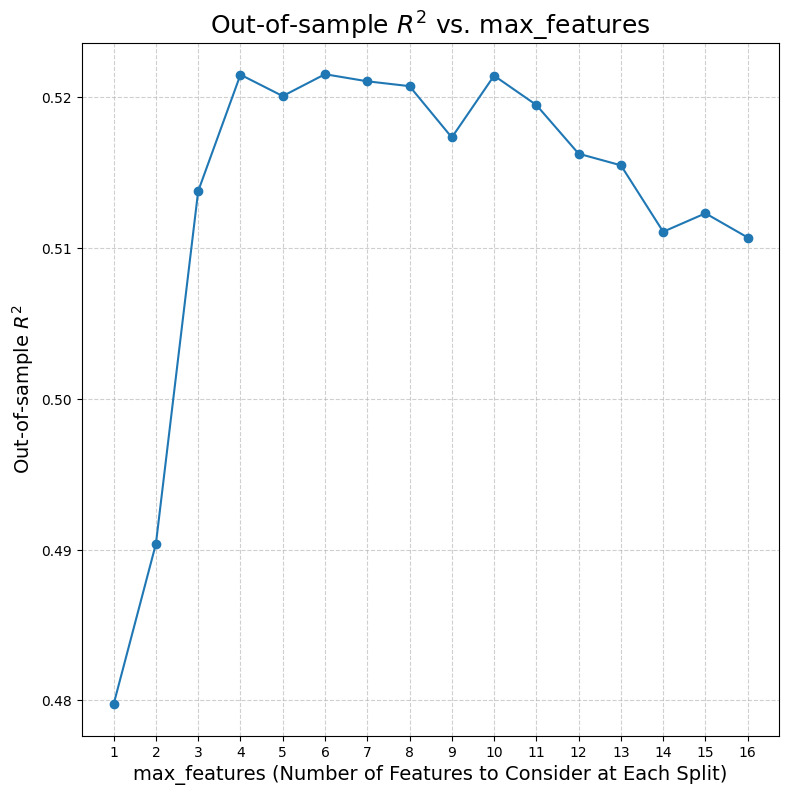


--- Plotting Out-of-sample R^2 vs. max_features ---


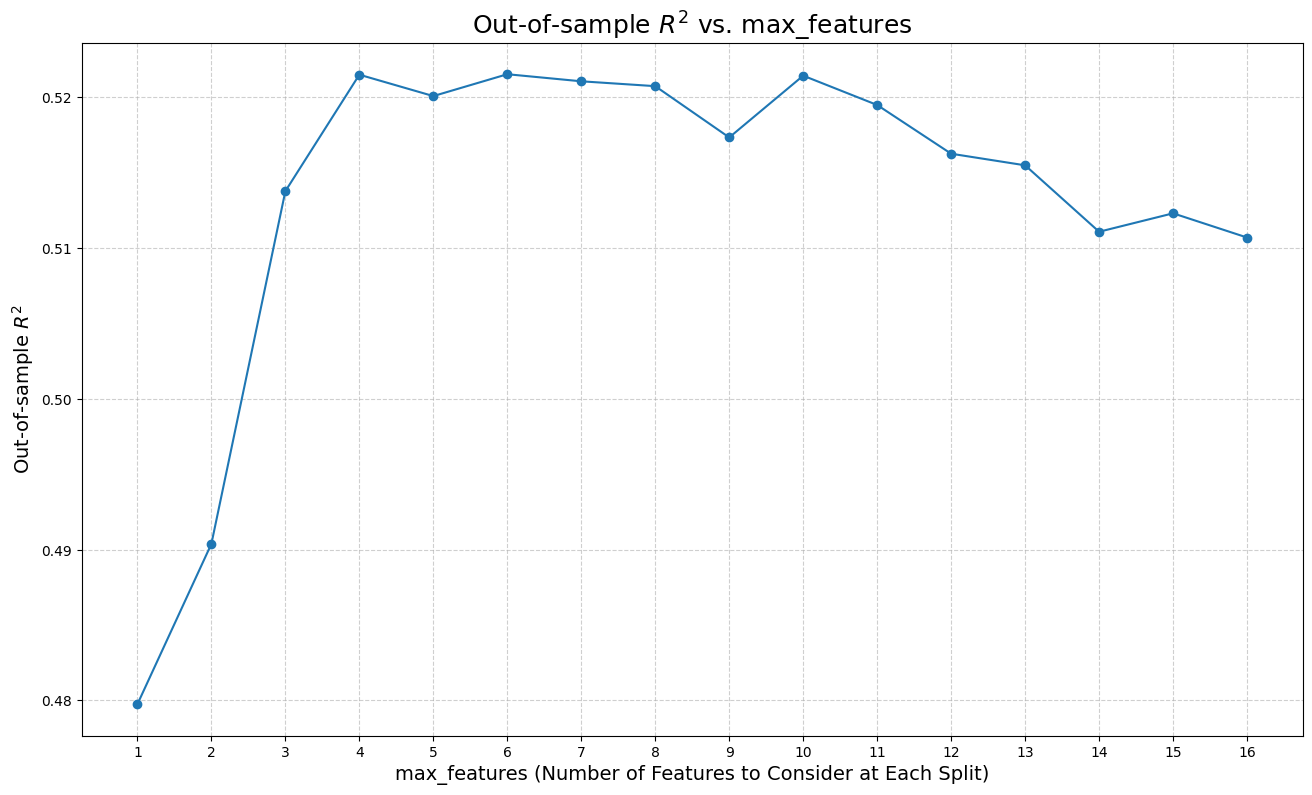


--- Plotting Computation Time vs. max_features ---


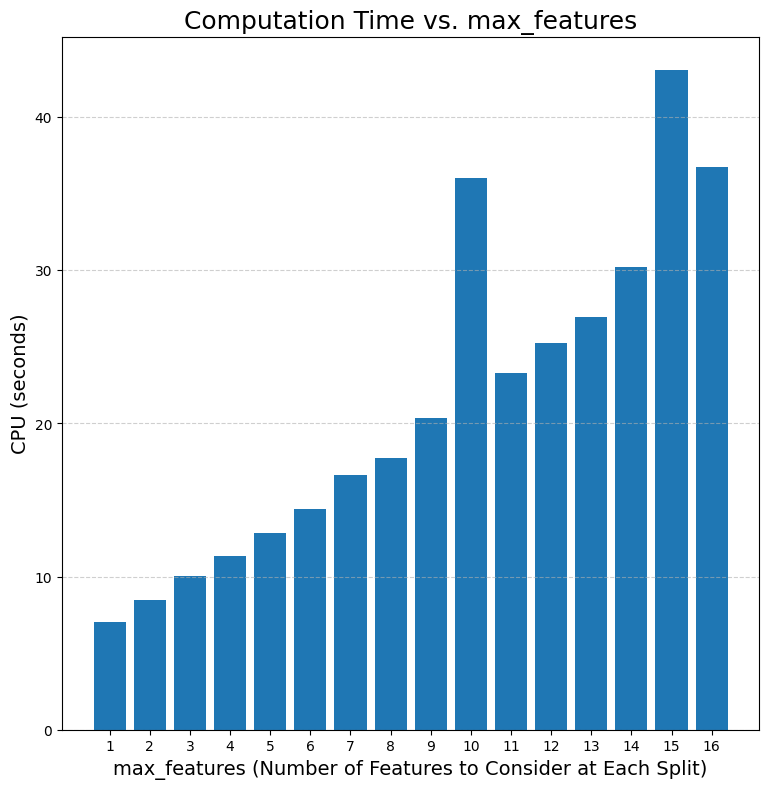


### 5. Final Model & Variable Importance ###
Final model fitted.

--- Variable Importance ---
          Variable  Importance
5      advCTRInPos    0.306434
4           advCTR    0.187551
7    queryCTRInPos    0.176488
6         queryCTR    0.115187
1          adWords    0.059011
0       titleWords    0.058265
2            depth    0.023824
3         position    0.014111
8      gender_male    0.009692
11       age_19-24    0.008618
15     age_unknown    0.008314
9   gender_unknown    0.007644
12       age_25-30    0.006903
13       age_31-40    0.006638
10       age_13-18    0.005828
14         age_41+    0.005491


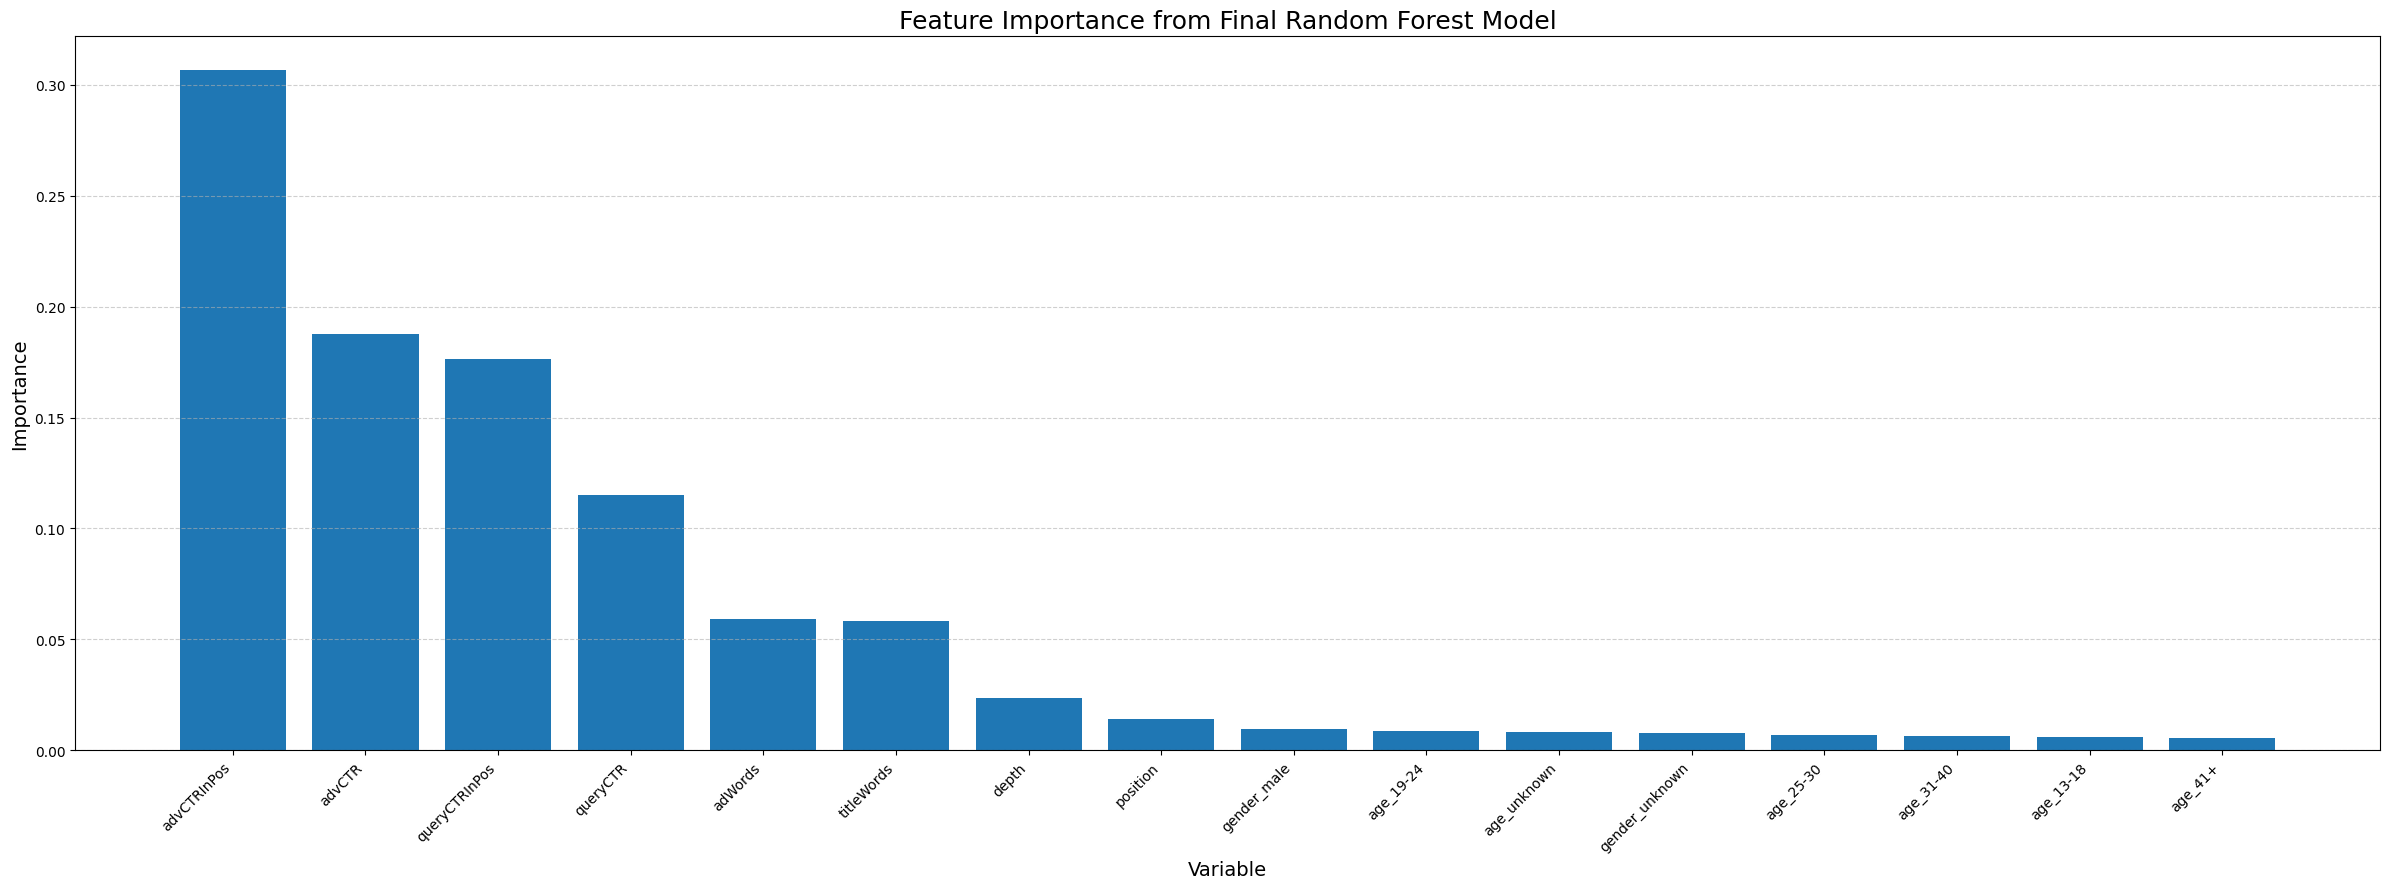


Final Model performance calculated.

### 6. Performance Summary of All Models ###
                    OSR^2     MAE    RMSE
Linear Regression  0.3961  0.0331  0.0551
CART               0.3377  0.0340  0.0577
RF (Ad-hoc 1)      0.4781  0.0310  0.0512
RF (Ad-hoc 2)      0.4117  0.0332  0.0544
RF (Final)         0.4940  0.0304  0.0504

### 7. Exploratory Tuning: `n_estimators` with 10-Fold CV ###
Testing n_estimators = 1...
Testing n_estimators = 5...
Testing n_estimators = 10...
Testing n_estimators = 20...
Testing n_estimators = 50...
Testing n_estimators = 100...
Testing n_estimators = 200...
Testing n_estimators = 500...
Testing n_estimators = 1000...
n_estimators tuning completed in 133.87 seconds.
 n_estimators      CV_R2 CPU_Time_sec
            1 0.31639178         0.12
            5 0.45411513         0.37
           10 0.47585730         0.70
           20 0.48702880         1.29
           50 0.49573107         3.14
          100 0.49757783         9.76
          200 0.4968064

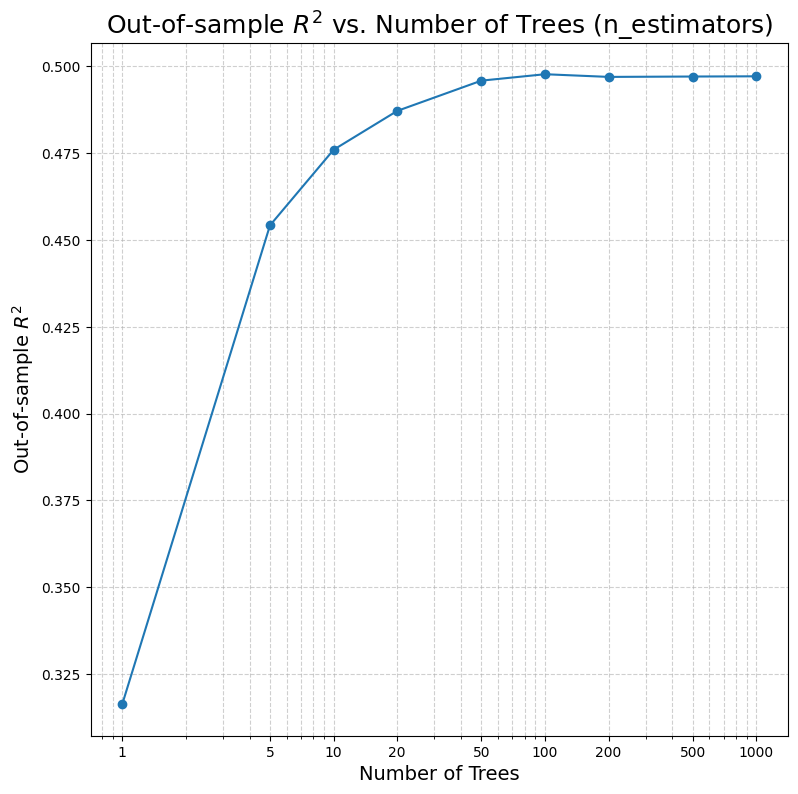


--- Plotting Computation Time vs. n_estimators ---


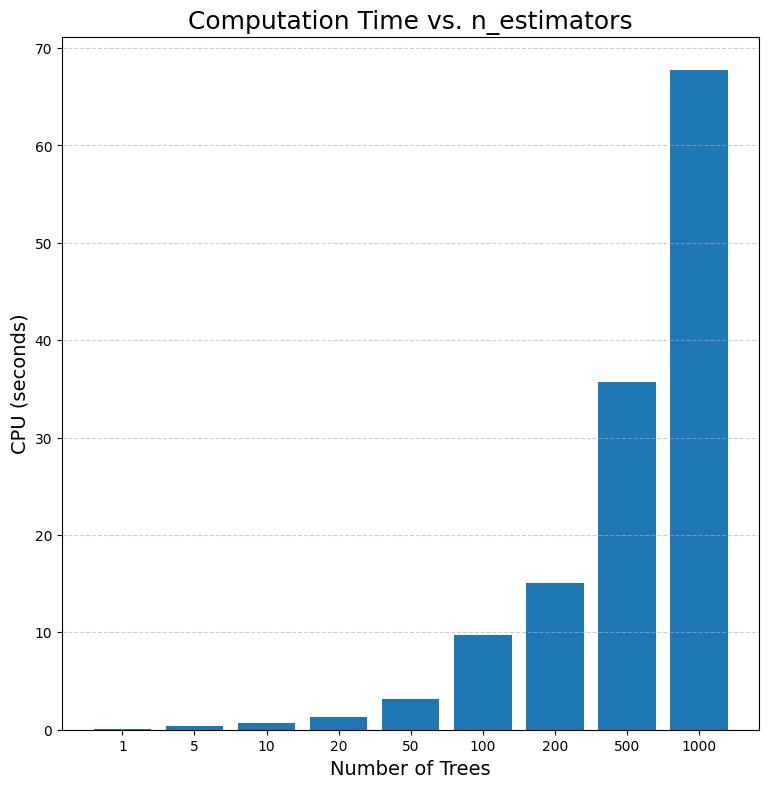


### 8. Exploratory Tuning: `min_samples_leaf` with 10-Fold CV ###
Testing min_samples_leaf = 1...
Testing min_samples_leaf = 2...


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import time
import os # Import os to set environment variable

# Suppress harmless MallocStackLogging warning on macOS when using n_jobs=-1
# This is set based on your feedback from a previous run.
os.environ['OBJC_DISABLE_INITIALIZE_FOR_FORK'] = 'YES'

# --- Helper Functions ---

def osr2(y_true, y_pred, baseline_mean):
    """Calculates the out-of-sample R-squared."""
    sst = np.sum((y_true - baseline_mean)**2)
    sse = np.sum((y_pred - y_true)**2)
    if sst == 0:
        return -np.inf if sse > 0 else 1.0
    return 1 - sse / sst

# --- Main Script ---

# 1. Import and Prepare Data
print("### 1. Importing and Preparing Data ###")
try:
    dat = pd.read_csv("CTR.csv")
    print("Successfully loaded CTR.csv")
except FileNotFoundError:
    print("Error: CTR.csv not found. Please ensure it's in the correct directory.")
    exit()

X = dat.drop('CTR', axis=1)
y = dat['CTR']
X = pd.get_dummies(X, drop_first=True, dtype=float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=144)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


# 2. Baseline Models
print("\n### 2. Baseline Models ###")

# Linear Regression
print("Fitting Baseline Linear Regression...")
X_train_lm = sm.add_constant(X_train, has_constant='add')
X_test_lm = sm.add_constant(X_test, has_constant='add').reindex(columns=X_train_lm.columns, fill_value=0)
mod_lm = sm.OLS(y_train, X_train_lm).fit()
pred_lm = mod_lm.predict(X_test_lm)
osr2_lm = osr2(y_test, pred_lm, y_train.mean())
mae_lm = mean_absolute_error(y_test, pred_lm)
rmse_lm = np.sqrt(mean_squared_error(y_test, pred_lm))
print("Linear Regression performance calculated.")

# CART
print("Fitting Baseline CART Model...")

# --- Time a SINGLE CART fit (NEW) ---
print("Timing a single CART model fit...")
single_cart_start_time = time.time()
single_cart = DecisionTreeRegressor(min_samples_leaf=5, max_depth=6, random_state=144)
single_cart.fit(X_train, y_train) # Fit on the full training set
single_cart_end_time = time.time()
single_cart_fit_time_ms = (single_cart_end_time - single_cart_start_time) * 1000
print(f"Time to fit one single CART model: {single_cart_fit_time_ms:.2f} ms")
# --- End of single CART timing (NEW) ---

# Define param_grid for CART before using it
cart_param_grid = {'ccp_alpha': np.arange(0, 0.01, 0.0005)}
modClass = DecisionTreeRegressor(
    min_samples_leaf=5,
    max_depth=6
)

cv_strategy = KFold(n_splits=10, shuffle=True, random_state=144)
search = GridSearchCV(
    estimator=modClass,
    param_grid=cart_param_grid, # Use the defined param_grid
    cv=cv_strategy,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# --- Time the CART fit ---
cart_start_time = time.time()
search.fit(X_train, y_train)
cart_end_time = time.time()
cart_fit_time_ms = (cart_end_time - cart_start_time) * 1000
print(f"CART GridSearchCV fit time: {cart_fit_time_ms:.2f} ms")
# --- End of timing ---

mod_cart = search.best_estimator_
pred_cart = mod_cart.predict(X_test)
osr2_cart = osr2(y_test, pred_cart, y_train.mean())
mae_cart = mean_absolute_error(y_test, pred_cart)
rmse_cart = np.sqrt(mean_squared_error(y_test, pred_cart))
print("CART performance calculated.")


# 3. Ad-hoc Random Forest Models
print("\n### 3. Ad-hoc Random Forest Models ###")

# Model 1
print("Fitting RF Model 1 (nodesize=5, max_features=3)...")
rf_mod1 = RandomForestRegressor(min_samples_leaf=5, max_features=3, random_state=144, n_jobs=-1)
rf_mod1.fit(X_train, y_train)
pred_rf1 = rf_mod1.predict(X_test)
osr2_rf1 = osr2(y_test, pred_rf1, y_train.mean())
mae_rf1 = mean_absolute_error(y_test, pred_rf1)
rmse_rf1 = np.sqrt(mean_squared_error(y_test, pred_rf1))
print("Model 1 performance calculated.")

# Model 2
print("Fitting RF Model 2 (nodesize=20, max_features=2, ntree=500)...")
rf_mod2 = RandomForestRegressor(min_samples_leaf=20, max_features=2, n_estimators=500, random_state=144, n_jobs=-1)
rf_mod2.fit(X_train, y_train)
pred_rf2 = rf_mod2.predict(X_test)
osr2_rf2 = osr2(y_test, pred_rf2, y_train.mean())
mae_rf2 = mean_absolute_error(y_test, pred_rf2)
rmse_rf2 = np.sqrt(mean_squared_error(y_test, pred_rf2))
print("Model 2 performance calculated.")


# 4. Hyperparameter Tuning with K-Fold Cross-Validation (CV)
print("\n### 4. Tuning `max_features` with 10-Fold CV ###")
max_features_values = range(1, X_train.shape[1] + 1)
cv_r2_scores_mf = []
cv_rmse_scores_mf = []
cv_mae_scores_mf = []
cv_times_mf = [] # New list to store computation time
start_time_total = time.time()

# Set up the K-fold strategy
kf = KFold(n_splits=10, shuffle=True, random_state=144)

for max_features in max_features_values:
    print(f"Testing max_features = {max_features}...")
    start_param_time = time.time() # Time this parameter value
    fold_r2_scores = []
    fold_rmse_scores = []
    fold_mae_scores = []

    # Manually loop through each fold
    # We use .iloc here to handle numpy array slicing from KFold
    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        rf_cv = RandomForestRegressor(
            max_features=max_features,
            random_state=144,
            n_jobs=1
        )
        rf_cv.fit(X_train_fold, y_train_fold)

        # Predict on the hold-out validation fold
        val_preds = rf_cv.predict(X_val_fold)

        # Calculate and store scores for this fold
        fold_r2 = r2_score(y_val_fold, val_preds)
        fold_rmse = np.sqrt(mean_squared_error(y_val_fold, val_preds))
        fold_mae = mean_absolute_error(y_val_fold, val_preds)

        fold_r2_scores.append(fold_r2)
        fold_rmse_scores.append(fold_rmse)
        fold_mae_scores.append(fold_mae)

    # Record time for this parameter
    end_param_time = time.time()
    cv_times_mf.append(end_param_time - start_param_time)

    # Average the scores across all 10 folds for this max_features value
    cv_r2_scores_mf.append(np.mean(fold_r2_scores))
    cv_rmse_scores_mf.append(np.mean(fold_rmse_scores))
    cv_mae_scores_mf.append(np.mean(fold_mae_scores))

end_time_total = time.time()
print(f"CV tuning for max_features completed in {end_time_total - start_time_total:.2f} seconds.")

# Create DataFrame for results
cv_results_mf = pd.DataFrame({
    'max_features': max_features_values,
    'CV_RMSE': cv_rmse_scores_mf,
    'CV_R2': cv_r2_scores_mf,
    'CV_MAE': cv_mae_scores_mf,
    'CPU_Time_sec': cv_times_mf # Add time to results
})

# Reorder columns to match the screenshot style
cv_results_mf = cv_results_mf[['max_features', 'CV_RMSE', 'CV_R2', 'CV_MAE', 'CPU_Time_sec']]

# --- Print the results table ---
print("\n--- CV Tuning Results for max_features ---")
print(cv_results_mf.to_string(index=False, formatters={
    'CV_RMSE': '{:,.8f}'.format,
    'CV_R2': '{:,.8f}'.format,
    'CV_MAE': '{:,.8f}'.format,
    'CPU_Time_sec': '{:,.2f}'.format
}))
# --- End of table print ---

best_max_features = int(cv_results_mf.loc[cv_results_mf['CV_R2'].idxmax()]['max_features'])
print(f"\nOptimal max_features based on Out-of-sample R^2: {best_max_features}") # Changed label

# Plotting CV results (Square)
print("\n--- Plotting Out-of-sample R^2 vs. max_features ---")
plt.figure(figsize=(9, 9)) # Square
plt.plot(cv_results_mf['max_features'], cv_results_mf['CV_R2'], marker='o', linestyle='-')
plt.title(r'Out-of-sample $R^2$ vs. max_features', fontsize=18)
plt.xlabel('max_features (Number of Features to Consider at Each Split)', fontsize=14)
plt.ylabel(r'Out-of-sample $R^2$', fontsize=14)
plt.xticks(max_features_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plotting CV results (Rectangular)
print("\n--- Plotting Out-of-sample R^2 vs. max_features ---")
plt.figure(figsize=(15.75, 9))
plt.plot(cv_results_mf['max_features'], cv_results_mf['CV_R2'], marker='o', linestyle='-')
plt.title(r'Out-of-sample $R^2$ vs. max_features', fontsize=18)
plt.xlabel('max_features (Number of Features to Consider at Each Split)', fontsize=14)
plt.ylabel(r'Out-of-sample $R^2$', fontsize=14)
plt.xticks(max_features_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


print("\n--- Plotting Computation Time vs. max_features ---")
plt.figure(figsize=(9, 9)) # Square
plt.bar(cv_results_mf['max_features'], cv_results_mf['CPU_Time_sec'])
plt.title('Computation Time vs. max_features', fontsize=18)
plt.xlabel('max_features (Number of Features to Consider at Each Split)', fontsize=14)
plt.ylabel('CPU (seconds)', fontsize=14)
plt.xticks(max_features_values)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()


# 5. Final Model & Variable Importance
print("\n### 5. Final Model & Variable Importance ###")
mod_rf_final = RandomForestRegressor(
    max_features=best_max_features,
    random_state=144, # oob_score not needed as we fit on all train data
    n_jobs=-1
)
mod_rf_final.fit(X_train, y_train)
print("Final model fitted.")

# Variable Importance
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': mod_rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- Variable Importance ---")
print(importance_df)


# Plotting Variable Importance
plt.figure(figsize=(24, 9)) # Changed from (15.75, 9)
plt.bar(importance_df['Variable'], importance_df['Importance']) # Changed to vertical bar
plt.xlabel('Variable', fontsize=14) # Swapped labels
plt.ylabel('Importance', fontsize=14) # Swapped labels
plt.title('Feature Importance from Final Random Forest Model', fontsize=18)
plt.xticks(rotation=45, ha='right') # Changed rotation to 45 (diagonal) and set horizontal alignment
plt.grid(True, axis='y', linestyle='--', alpha=0.6) # Grid on y-axis
plt.tight_layout() # Add tight_layout to prevent labels from being cut off
plt.show()

# Performance of Final Model
pred_rf_final = mod_rf_final.predict(X_test)
osr2_rf_final = osr2(y_test, pred_rf_final, y_train.mean())
mae_rf_final = mean_absolute_error(y_test, pred_rf_final)
rmse_rf_final = np.sqrt(mean_squared_error(y_test, pred_rf_final))
print("\nFinal Model performance calculated.")


# 6. Summary of all methods
print("\n### 6. Performance Summary of All Models ###")
summary_stats = pd.DataFrame({
    'OSR^2': [osr2_lm, osr2_cart, osr2_rf1, osr2_rf2, osr2_rf_final],
    'MAE': [mae_lm, mae_cart, mae_rf1, mae_rf2, mae_rf_final],
    'RMSE': [rmse_lm, rmse_cart, rmse_rf1, rmse_rf2, rmse_rf_final]
}, index=['Linear Regression', 'CART', 'RF (Ad-hoc 1)', 'RF (Ad-hoc 2)', 'RF (Final)'])

print(summary_stats.round(4))


# 7. Exploratory Tuning: n_estimators
print("\n### 7. Exploratory Tuning: `n_estimators` with 10-Fold CV ###")
ntree_values = [1, 5, 10, 20, 50, 100, 200, 500, 1000]
cv_r2_scores_nt = []
cv_times_nt = [] # New list for timing
start_time_total = time.time()

for ntree in ntree_values:
    print(f"Testing n_estimators = {ntree}...")
    start_param_time = time.time() # Time this parameter value
    fold_r2_scores = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        rf_ntree = RandomForestRegressor(
            n_estimators=ntree,
            max_features='sqrt', # Use a common default
            min_samples_leaf=5,  # Use a common default
            random_state=144,
            n_jobs=1
        )
        rf_ntree.fit(X_train_fold, y_train_fold)
        val_preds = rf_ntree.predict(X_val_fold)
        fold_r2_scores.append(r2_score(y_val_fold, val_preds))

    end_param_time = time.time()
    cv_times_nt.append(end_param_time - start_param_time)
    cv_r2_scores_nt.append(np.mean(fold_r2_scores))

end_time_total = time.time()
print(f"n_estimators tuning completed in {end_time_total - start_time_total:.2f} seconds.")

ntree_results = pd.DataFrame({
    'n_estimators': ntree_values,
    'CV_R2': cv_r2_scores_nt,
    'CPU_Time_sec': cv_times_nt # Add time
})
print(ntree_results.to_string(index=False, formatters={'CV_R2': '{:,.8f}'.format, 'CPU_Time_sec': '{:,.2f}'.format}))

# Plotting the results
plt.figure(figsize=(9, 9)) # Square
plt.plot(ntree_results['n_estimators'], ntree_results['CV_R2'], marker='o', linestyle='-')
plt.title(r'Out-of-sample $R^2$ vs. Number of Trees (n_estimators)', fontsize=18) # Changed label
plt.xlabel('Number of Trees', fontsize=14)
plt.ylabel(r'Out-of-sample $R^2$', fontsize=14) # Changed label
plt.xscale('log')
plt.xticks(ntree_values, labels=ntree_values)
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.show()

# --- NEW PLOT: CPU Time vs. n_estimators ---
print("\n--- Plotting Computation Time vs. n_estimators ---")
plt.figure(figsize=(9, 9)) # Square
# Convert n_estimators to string for a categorical bar plot
ntree_labels = [str(n) for n in ntree_results['n_estimators']]
plt.bar(ntree_labels, ntree_results['CPU_Time_sec'])
plt.title('Computation Time vs. n_estimators', fontsize=18)
plt.xlabel('Number of Trees', fontsize=14)
plt.ylabel('CPU (seconds)', fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()


# 8. Exploratory Tuning: min_samples_leaf
print("\n### 8. Exploratory Tuning: `min_samples_leaf` with 10-Fold CV ###")
nodesize_values = range(1, 21)
cv_r2_scores_ns = []
cv_times_ns = [] # New list for timing
start_time_total = time.time()

for nodesize in nodesize_values:
    print(f"Testing min_samples_leaf = {nodesize}...")
    start_param_time = time.time() # Time this parameter value
    fold_r2_scores = []

    for train_index, val_index in kf.split(X_train):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        rf_nodesize = RandomForestRegressor(
            n_estimators=200,     # Use a reasonably high ntree
            max_features='sqrt', # Use a common default
            min_samples_leaf=nodesize,
            random_state=144,
            n_jobs=1
        )
        rf_nodesize.fit(X_train_fold, y_train_fold)
        val_preds = rf_nodesize.predict(X_val_fold)
        fold_r2_scores.append(r2_score(y_val_fold, val_preds))

    end_param_time = time.time()
    cv_times_ns.append(end_param_time - start_param_time)
    cv_r2_scores_ns.append(np.mean(fold_r2_scores))

end_time_total = time.time()
print(f"min_samples_leaf tuning completed in {end_time_total - start_time_total:.2f} seconds.")

nodesize_results = pd.DataFrame({
    'min_samples_leaf': nodesize_values,
    'CV_R2': cv_r2_scores_ns,
    'CPU_Time_sec': cv_times_ns # Add time
})
print(nodesize_results.to_string(index=False, formatters={'CV_R2': '{:,.8f}'.format, 'CPU_Time_sec': '{:,.2f}'.format}))

# Plotting the results
plt.figure(figsize=(9, 9)) # Square
plt.plot(nodesize_results['min_samples_leaf'], nodesize_results['CV_R2'], marker='o', linestyle='-')
plt.title(r'Out-of-sample $R^2$ vs. Node Size (min_samples_leaf)', fontsize=18) # Changed title
plt.xlabel('Minimum Samples per Leaf', fontsize=14)
plt.ylabel(r'Out-of-sample $R^2$', fontsize=14) # Changed label
plt.xticks(nodesize_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- NEW PLOT: CPU Time vs. min_samples_leaf ---
print("\n--- Plotting Computation Time vs. min_samples_leaf ---")
plt.figure(figsize=(9, 9)) # Square
plt.bar(nodesize_results['min_samples_leaf'], nodesize_results['CPU_Time_sec'])
plt.title('Computation Time vs. min_samples_leaf', fontsize=18)
plt.xlabel('Minimum Samples per Leaf', fontsize=14)
plt.ylabel('CPU (seconds)', fontsize=14)
plt.xticks(nodesize_values)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()



### "Out of Bag" (OOB) hyperparameter tuning

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import time

# --- Helper Functions ---

def osr2(y_true, y_pred, baseline_mean):
    """Calculates the out-of-sample R-squared."""
    sst = np.sum((y_true - baseline_mean)**2)
    sse = np.sum((y_pred - y_true)**2)
    if sst == 0:
        return -np.inf if sse > 0 else 1.0
    return 1 - sse / sst

# --- Main Script ---

# 1. Import and Prepare Data
print("### 1. Importing and Preparing Data ###")
try:
    dat = pd.read_csv("CTR.csv")
    print("Successfully loaded CTR.csv")
except FileNotFoundError:
    print("Error: CTR.csv not found. Please ensure it's in the correct directory.")
    exit()

X = dat.drop('CTR', axis=1)
y = dat['CTR']
X = pd.get_dummies(X, drop_first=True, dtype=float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=144)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


# 2. Baseline Models
print("\n### 2. Baseline Models ###")

# Linear Regression
print("Fitting Baseline Linear Regression...")
X_train_lm = sm.add_constant(X_train, has_constant='add')
X_test_lm = sm.add_constant(X_test, has_constant='add').reindex(columns=X_train_lm.columns, fill_value=0)
mod_lm = sm.OLS(y_train, X_train_lm).fit()
pred_lm = mod_lm.predict(X_test_lm)
osr2_lm = osr2(y_test, pred_lm, y_train.mean())
mae_lm = mean_absolute_error(y_test, pred_lm)
rmse_lm = np.sqrt(mean_squared_error(y_test, pred_lm))
print("Linear Regression performance calculated.")

# CART
print("Fitting Baseline CART Model...")
# Define param_grid for CART before using it
cart_param_grid = {'ccp_alpha': np.arange(0, 0.01, 0.0005)}
modClass = DecisionTreeRegressor(
    min_samples_leaf=5,
    max_depth=6
)

cv_strategy = KFold(n_splits=10, shuffle=True, random_state=144)
search = GridSearchCV(
    estimator=modClass,
    param_grid=cart_param_grid, # Use the defined param_grid
    cv=cv_strategy,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
search.fit(X_train, y_train)
mod_cart = search.best_estimator_
pred_cart = mod_cart.predict(X_test)
osr2_cart = osr2(y_test, pred_cart, y_train.mean())
mae_cart = mean_absolute_error(y_test, pred_cart)
rmse_cart = np.sqrt(mean_squared_error(y_test, pred_cart))
print("CART performance calculated.")


# 3. Ad-hoc Random Forest Models
print("\n### 3. Ad-hoc Random Forest Models ###")

# Model 1
print("Fitting RF Model 1 (nodesize=5, max_features=3)...")
rf_mod1 = RandomForestRegressor(min_samples_leaf=5, max_features=3, random_state=144, n_jobs=-1)
rf_mod1.fit(X_train, y_train)
pred_rf1 = rf_mod1.predict(X_test)
osr2_rf1 = osr2(y_test, pred_rf1, y_train.mean())
mae_rf1 = mean_absolute_error(y_test, pred_rf1)
rmse_rf1 = np.sqrt(mean_squared_error(y_test, pred_rf1))
print("Model 1 performance calculated.")

# Model 2
print("Fitting RF Model 2 (nodesize=20, max_features=2, ntree=500)...")
rf_mod2 = RandomForestRegressor(min_samples_leaf=20, max_features=2, n_estimators=500, random_state=144, n_jobs=-1)
rf_mod2.fit(X_train, y_train)
pred_rf2 = rf_mod2.predict(X_test)
osr2_rf2 = osr2(y_test, pred_rf2, y_train.mean())
mae_rf2 = mean_absolute_error(y_test, pred_rf2)
rmse_rf2 = np.sqrt(mean_squared_error(y_test, pred_rf2))
print("Model 2 performance calculated.")


# 4. Hyperparameter Tuning with Out-of-Bag (OOB) Score
print("\n### 4. Tuning `max_features` with Out-of-Bag Score ###")
max_features_values = range(1, X_train.shape[1] + 1)
oob_r2_scores = []
oob_rmse_scores = [] # New list for RMSE
oob_mae_scores = []  # New list for MAE
start_time = time.time()

for max_features in max_features_values:
    print(f"Testing max_features = {max_features}...")
    rf_oob = RandomForestRegressor(
        max_features=max_features,
        oob_score=True,
        random_state=144,
        n_jobs=-1
    )
    rf_oob.fit(X_train, y_train)

    # Store the OOB R^2 score
    oob_r2_scores.append(rf_oob.oob_score_)

    # Get OOB predictions
    oob_predictions = rf_oob.oob_prediction_

    # Filter out samples that were never OOB (NaNs)
    valid_oob_indices = ~np.isnan(oob_predictions)
    valid_oob_preds = oob_predictions[valid_oob_indices]
    valid_y_train = y_train.iloc[valid_oob_indices]

    # Calculate metrics on valid OOB predictions
    oob_rmse = np.sqrt(mean_squared_error(valid_y_train, valid_oob_preds))
    oob_mae = mean_absolute_error(valid_y_train, valid_oob_preds)

    # Store the new metrics
    oob_rmse_scores.append(oob_rmse)
    oob_mae_scores.append(oob_mae)

end_time = time.time()
print(f"OOB tuning completed in {end_time - start_time:.2f} seconds.")

# Update DataFrame to include all metrics
oob_results = pd.DataFrame({
    'max_features': max_features_values,
    'OOB_RMSE': oob_rmse_scores,
    'OOB_R2': oob_r2_scores,
    'OOB_MAE': oob_mae_scores
})

# Reorder columns to match the screenshot
oob_results = oob_results[['max_features', 'OOB_RMSE', 'OOB_R2', 'OOB_MAE']]

# --- Print the results table ---
print("\n--- OOB Tuning Results ---")
print(oob_results.to_string(index=False, formatters={
    'OOB_RMSE': '{:,.8f}'.format,
    'OOB_R2': '{:,.8f}'.format,
    'OOB_MAE': '{:,.8f}'.format
}))
# --- End of table print ---

best_max_features = int(oob_results.loc[oob_results['OOB_R2'].idxmax()]['max_features'])
print(f"\nOptimal max_features based on OOB R^2: {best_max_features}")

# Plotting OOB results
plt.figure(figsize=(9, 9)) # Changed to square
plt.plot(oob_results['max_features'], oob_results['OOB_R2'], marker='o', linestyle='-')
plt.title(r'Out-of-Bag $R^2$ vs. max_features', fontsize=18)
plt.xlabel('max_features (Number of Features to Consider at Each Split)', fontsize=14)
plt.ylabel(r'Out-of-Bag $R^2$', fontsize=14)
plt.xticks(max_features_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(15.75, 9))
plt.plot(oob_results['max_features'], oob_results['OOB_R2'], marker='o', linestyle='-')
plt.title(r'Out-of-Bag $R^2$ vs. max_features', fontsize=18)
plt.xlabel('max_features (Number of Features to Consider at Each Split)', fontsize=14)
plt.ylabel(r'Out-of-Bag $R^2$', fontsize=14)
plt.xticks(max_features_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# 5. Final Model & Variable Importance
print("\n### 5. Final Model & Variable Importance ###")
mod_rf_final = RandomForestRegressor(
    max_features=best_max_features,
    oob_score=True,
    random_state=144,
    n_jobs=-1
)
mod_rf_final.fit(X_train, y_train)
print("Final model fitted.")

# Variable Importance
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': mod_rf_final.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- Variable Importance ---")
print(importance_df)


# Plotting Variable Importance
plt.figure(figsize=(9, 9)) # Changed to square
plt.barh(importance_df['Variable'], importance_df['Importance'])
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Variable', fontsize=14)
plt.title('Feature Importance from Final Random Forest Model', fontsize=18)
plt.gca().invert_yaxis()
plt.show()

# Performance of Final Model
pred_rf_final = mod_rf_final.predict(X_test)
osr2_rf_final = osr2(y_test, pred_rf_final, y_train.mean())
mae_rf_final = mean_absolute_error(y_test, pred_rf_final)
rmse_rf_final = np.sqrt(mean_squared_error(y_test, pred_rf_final))
print("\nFinal Model performance calculated.")


# 6. Summary of all methods
print("\n### 6. Performance Summary of All Models ###")
summary_stats = pd.DataFrame({
    'OSR^2': [osr2_lm, osr2_cart, osr2_rf1, osr2_rf2, osr2_rf_final],
    'MAE': [mae_lm, mae_cart, mae_rf1, mae_rf2, mae_rf_final],
    'RMSE': [rmse_lm, rmse_cart, rmse_rf1, rmse_rf2, rmse_rf_final]
}, index=['Linear Regression', 'CART', 'RF (Ad-hoc 1)', 'RF (Ad-hoc 2)', 'RF (Final OOB)'])

print(summary_stats.round(4))


# 7. Exploratory Tuning: n_estimators
print("\n### 7. Exploratory Tuning: `n_estimators` with Out-of-Bag Score ###")
ntree_values = [1, 5, 10, 20, 50, 100, 200, 500, 1000]
oob_r2_ntree = []
start_time = time.time()

for ntree in ntree_values:
    print(f"Testing n_estimators = {ntree}...")
    rf_ntree = RandomForestRegressor(
        n_estimators=ntree,
        max_features='sqrt',
        min_samples_leaf=5,
        oob_score=True,
        random_state=144,
        n_jobs=-1
    )
    rf_ntree.fit(X_train, y_train)
    oob_r2_ntree.append(rf_ntree.oob_score_)

end_time = time.time()
print(f"n_estimators tuning completed in {end_time - start_time:.2f} seconds.")

ntree_results = pd.DataFrame({'n_estimators': ntree_values, 'OOB_R2': oob_r2_ntree})
print(ntree_results.to_string(index=False))

# Plotting the results
plt.figure(figsize=(9, 9)) # Changed to square
plt.plot(ntree_results['n_estimators'], ntree_results['OOB_R2'], marker='o', linestyle='-')
plt.title(r'Out-of-Bag $R^2$ vs. Number of Trees (n_estimators)', fontsize=18)
plt.xlabel('Number of Trees', fontsize=14)
plt.ylabel(r'Out-of-Bag $R^2$', fontsize=14)
plt.xscale('log')
plt.xticks(ntree_values, labels=ntree_values)
plt.grid(True, which="both", linestyle='--', alpha=0.6)
plt.show()


# 8. Exploratory Tuning: min_samples_leaf
print("\n### 8. Exploratory Tuning: `min_samples_leaf` with Out-of-Bag Score ###")
nodesize_values = range(1, 21)
oob_r2_nodesize = []
start_time = time.time()

for nodesize in nodesize_values:
    print(f"Testing min_samples_leaf = {nodesize}...")
    rf_nodesize = RandomForestRegressor(
        n_estimators=200,
        max_features='sqrt',
        min_samples_leaf=nodesize,
        oob_score=True,
        random_state=144,
        n_jobs=-1
    )
    rf_nodesize.fit(X_train, y_train)
    oob_r2_nodesize.append(rf_nodesize.oob_score_)

end_time = time.time()
print(f"min_samples_leaf tuning completed in {end_time - start_time:.2f} seconds.")

nodesize_results = pd.DataFrame({'min_samples_leaf': nodesize_values, 'OOB_R2': oob_r2_nodesize})
print(nodesize_results.to_string(index=False))

# Plotting the results
plt.figure(figsize=(9, 9)) # Changed to square
plt.plot(nodesize_results['min_samples_leaf'], nodesize_results['OOB_R2'], marker='o', linestyle='-')
plt.title(r'Out-of-Bag $R^2$ vs. Node Size (min_samples_leaf)', fontsize=18)
plt.xlabel('Minimum Samples per Leaf', fontsize=14)
plt.ylabel(r'Out-of-Bag $R^2$', fontsize=14)
plt.xticks(nodesize_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()